# Import dependencies and load data

In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

optir_data_folder = Path("optir_data")

amp_film_data = optir_data_folder / "AMP_films/AMP_thicklayer_rep_IR.csv"
amp_film_UHV_data = optir_data_folder / "AMP_films/AMP_thicklayer_UHV_IR.csv"

def load_ir_data(file_path):
    df = pd.read_csv(file_path, header=0)
    df = df.dropna(axis=1, how="all")
    df = df.apply(pd.to_numeric, errors='coerce')
    df = df.dropna(subset=[df.columns[0]])
    return df.astype(float)

df_amp_film = load_ir_data(amp_film_data)
df_amp_film_UHV = load_ir_data(amp_film_UHV_data)

# Plot raw data

<Figure size 1200x500 with 0 Axes>

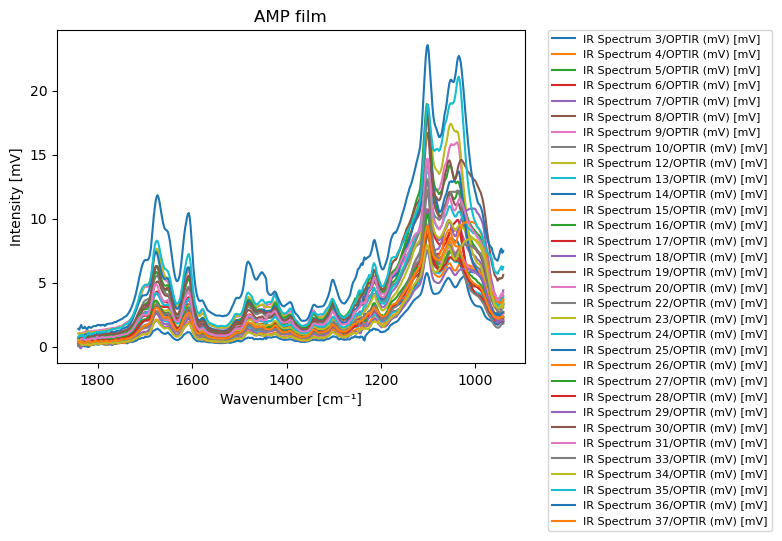

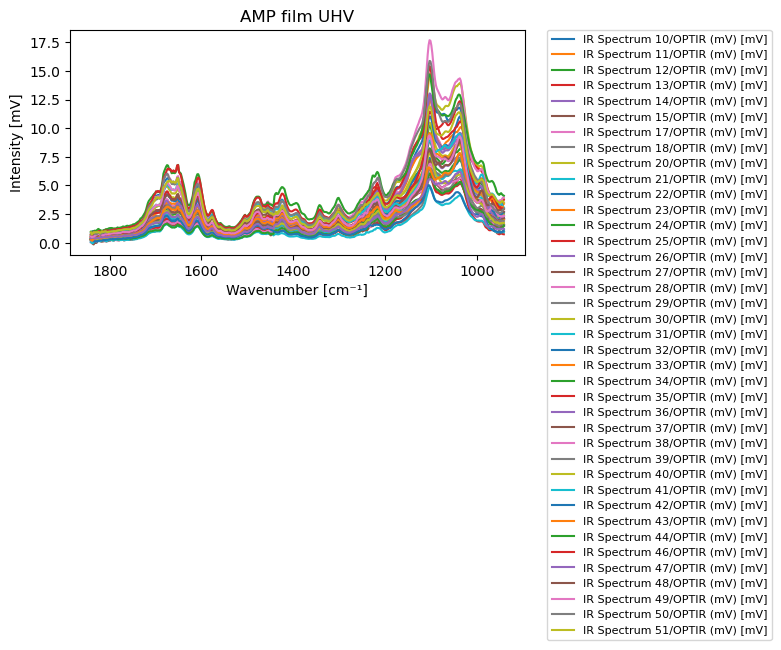

In [2]:
plt.figure(figsize=(12, 5))


def plot_spectra(df, title):
    x = df.iloc[:, 0].values        # first column = wavenumbers
    y_cols = df.columns[1:]         # remaining columns = spectra

    plt.figure(figsize=(8, 5))
    for col in y_cols:
        plt.plot(x, df[col].values, label=col)

    plt.xlabel("Wavenumber [cm⁻¹]")
    plt.ylabel("Intensity [mV]")
    plt.title(title)
    plt.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.05, 1), borderaxespad=0.)
    plt.gca().invert_xaxis()  # IR convention: decreasing wavenumber to the right
    plt.tight_layout()
    plt.show()


plot_spectra(df_amp_film, "AMP film")
plot_spectra(df_amp_film_UHV, "AMP film UHV")

# Normalise and plot

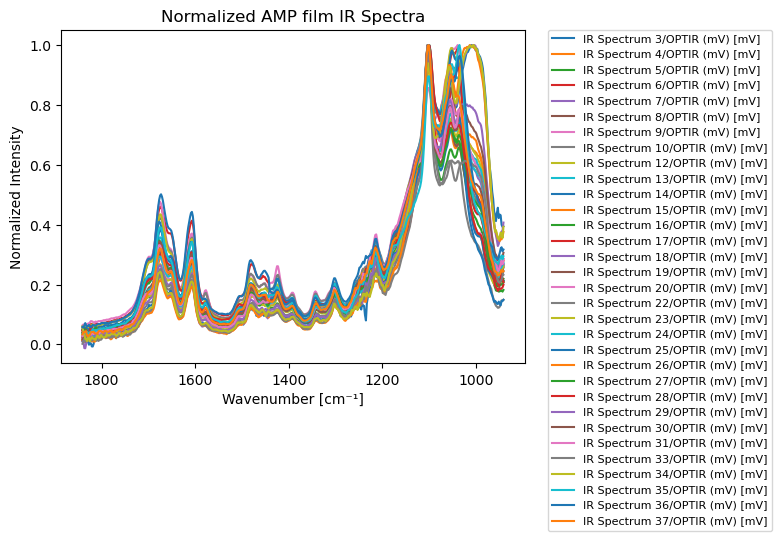

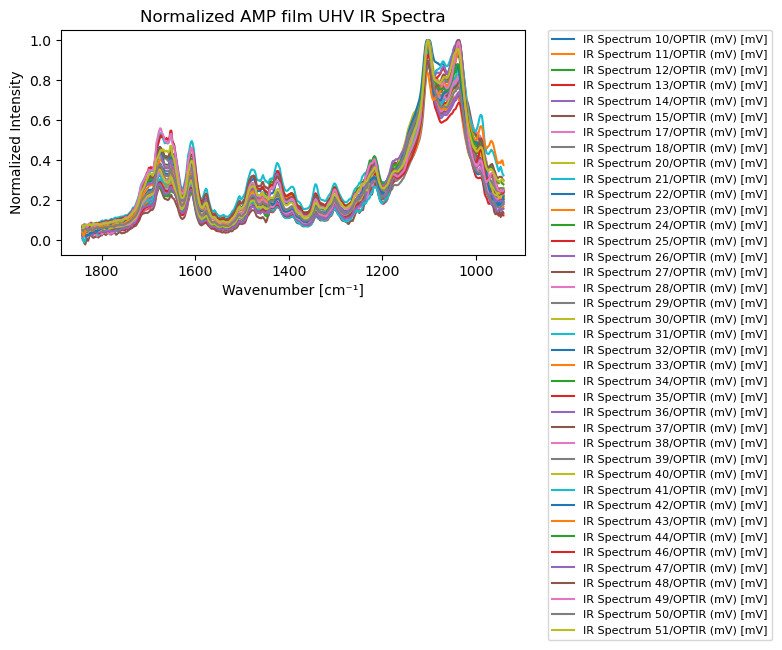

In [7]:
import numpy as np
import matplotlib.pyplot as plt


def normalize_spectra_region(df, region_low, region_high):
    """
    Normalize spectra so that each y-column has maximum = 1
    within the specified wavenumber region [region_low, region_high].
    
    df:
        DataFrame where df.iloc[:, 0] = wavenumber (x)
        and columns 1..n are spectra.

    Returns:
        normalized_df : DataFrame, same shape as df
    """

    # Extract x
    x = df.iloc[:, 0].astype(float).values

    # Identify rows within the region
    region_mask = (x >= region_low) & (x <= region_high)

    # Prepare output
    normalized_df = df.copy()
    y_cols = df.columns[1:]

    # Normalize each spectrum column independently
    for col in y_cols:
        y = df[col].astype(float).values
        max_val = np.nanmax(y[region_mask])
        if max_val == 0 or np.isnan(max_val):
            # Avoid division by zero; leave unchanged
            continue
        normalized_df[col] = y / max_val

    return normalized_df



def plot_normalized_spectra(df, title, region_low, region_high):
    """
    1) Normalize each spectrum so that its max within [region_low, region_high] is 1.
    2) Plot normalized spectra vs. wavenumber (column 0).
    """
    # Normalize in-place copy
    normalized_df = normalize_spectra_region(df, region_low, region_high)

    # Extract x (wavenumbers)
    x = normalized_df.iloc[:, 0].astype(float).values

    # Plot each spectrum column
    plt.figure(figsize=(8, 5))
    for col in normalized_df.columns[1:]:
        y = normalized_df[col].astype(float).values
        plt.plot(x, y, label=str(col))

    plt.xlabel("Wavenumber [cm⁻¹]")
    plt.ylabel("Normalized Intensity")
    plt.title(title)
    plt.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.05, 1), borderaxespad=0.)
    plt.gca().invert_xaxis()  # IR convention
    plt.tight_layout()
    plt.show()


# Example: Normalize and plot Group 1 spectra with cutoff at 1200 cm⁻¹
plot_normalized_spectra(df_amp_film, "Normalized AMP film IR Spectra", region_low=950, region_high=1200)

# Example: Normalize and plot Group 2 spectra with cutoff at 1200 cm⁻¹
plot_normalized_spectra(df_amp_film_UHV, "Normalized AMP film UHV IR Spectra", region_low=950, region_high=1200)


# Plot averages

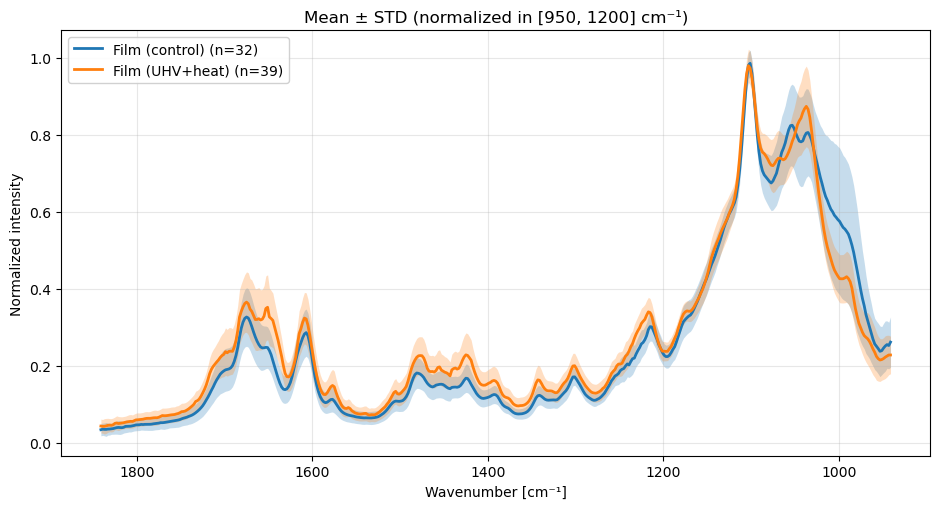

In [ ]:
def plot_two_group_averages_noalign(
    df1: pd.DataFrame,
    df2: pd.DataFrame,
    name1: str,
    name2: str,
    region_low: float,
    region_high: float,
    spread: str = "std",      # "std", "sem", or "ci95"
    invert_x: bool = True,
    show_region: bool = False,
    color1: str | None = None,
    color2: str | None = None,
):
    """
    Normalize df1 and df2 in [region_low, region_high], compute mean ± spread for each group,
    and plot both on the same axes. Requires identical x arrays.
    """
    # 1) Normalize both groups
    df1n = normalize_spectra_region(df1, region_low, region_high)
    df2n = normalize_spectra_region(df2, region_low, region_high)

    # 2) Extract and verify x (must be identical since no alignment is requested)
    x1 = pd.to_numeric(df1n.iloc[:, 0], errors='coerce').values
    x2 = pd.to_numeric(df2n.iloc[:, 0], errors='coerce').values
    if not np.array_equal(x1, x2):
        # If you want numerical tolerance instead, use: np.allclose(x1, x2, rtol=0, atol=1e-9)
        raise ValueError("x (wavenumber) grids differ between df1 and df2; alignment is disabled.")

    x = x1

    # 3) Stack spectra matrices
    Y1 = df1n.iloc[:, 1:].apply(pd.to_numeric, errors='coerce').values  # shape (n_points, n1)
    Y2 = df2n.iloc[:, 1:].apply(pd.to_numeric, errors='coerce').values  # shape (n_points, n2)

    # 4) Mean and spread (NaN-aware)
    def mean_and_band(Y: np.ndarray, spread: str):
        mean = np.nanmean(Y, axis=1)
        n = np.sum(~np.isnan(Y), axis=1)
        sd = np.nanstd(Y, axis=1, ddof=1)
        sd = np.where(n >= 2, sd, 0.0)  # avoid NaN when only one spectrum
        if spread == "std":
            band = sd
        elif spread == "sem":
            band = sd / np.sqrt(np.maximum(n, 1))
        elif spread == "ci95":
            band = 1.96 * sd / np.sqrt(np.maximum(n, 1))
        else:
            raise ValueError("spread must be 'std', 'sem', or 'ci95'.")
        return mean, band

    mean1, band1 = mean_and_band(Y1, spread)
    mean2, band2 = mean_and_band(Y2, spread)

    # 5) Plot
    plt.figure(figsize=(9.5, 5.2))
    if color1 is None or color2 is None:
        base = plt.rcParams['axes.prop_cycle'].by_key()['color']
        color1 = base[0] if color1 is None else color1
        color2 = base[1] if color2 is None else color2

    plt.plot(x, mean1, color=color1, lw=2, label=f"{name1} (n={Y1.shape[1]})")
    plt.fill_between(x, mean1 - band1, mean1 + band1, color=color1, alpha=0.25, linewidth=0)

    plt.plot(x, mean2, color=color2, lw=2, label=f"{name2} (n={Y2.shape[1]})")
    plt.fill_between(x, mean2 - band2, mean2 + band2, color=color2, alpha=0.25, linewidth=0)

    if show_region:
        plt.axvspan(region_low, region_high, color='grey', alpha=0.15, lw=0)

    plt.xlabel("Wavenumber [cm⁻¹]")
    plt.ylabel("Normalized intensity")
    plt.title(f"Mean ± {spread.upper()} (normalized in [{region_low}, {region_high}] cm⁻¹)")
    if invert_x:
        plt.gca().invert_xaxis()

    plt.legend(
        loc="upper left",
        frameon=True,
        facecolor="white",
        framealpha=0.9
    )
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# Your DataFrames
df1 = df_amp_film
df2 = df_amp_film_UHV

plot_two_group_averages_noalign(
    df1=df1,
    df2=df2,
    name1="Film (control)",
    name2="Film (UHV+heat)",
    region_low=950,
    region_high=1200,
    spread="std",         # or "sem", "ci95"
    invert_x=True,
    show_region=False
)